In [53]:
# Import all required modules
# Disable warnings
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# Import plotting modules and set up
import seaborn as sns

sns.set_theme()
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [54]:
# Tune the visual settings for figures in `seaborn`
sns.set_context(
    "notebook", font_scale=1.5, rc={"figure.figsize": (11, 8), "axes.titlesize": 18}
)

from matplotlib import rcParams

rcParams["figure.figsize"] = 11, 8

In [55]:
# for Jupyter-book, we copy data from GitHub, locally, to save Internet traffic,
# you can specify the data/ folder from the root of your cloned
# https://github.com/Yorko/mlcourse.ai repo, to save Internet traffic
DATA_PATH = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"

In [56]:
df = pd.read_csv(DATA_PATH + "mlbootcamp5_train.csv", sep=";")
print("Dataset size: ", df.shape)
df.head()

Dataset size:  (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


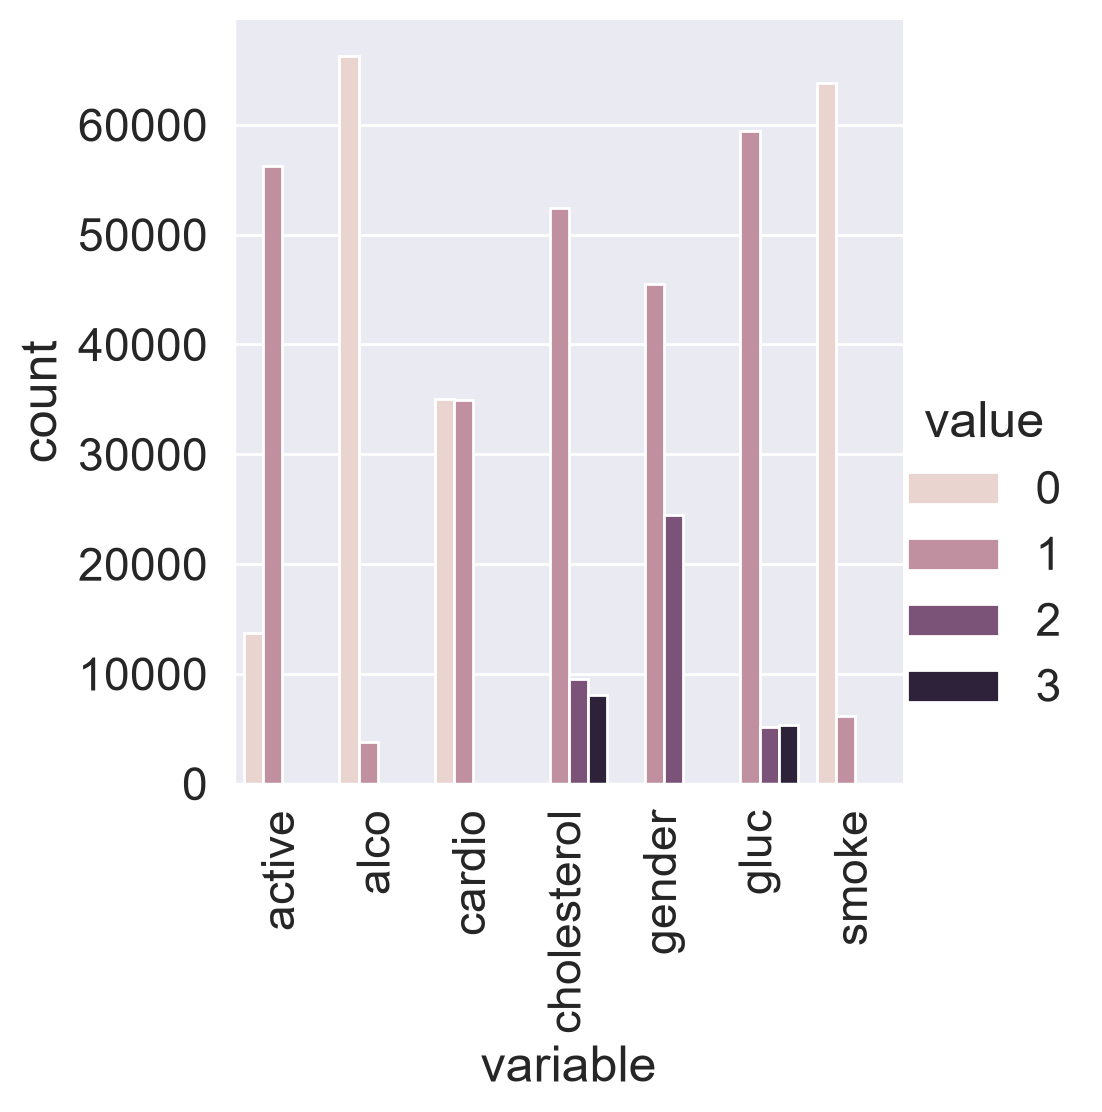

In [57]:
df_uniques = pd.melt(
    frame=df,
    value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active", "cardio"],
)
df_uniques = (
    pd.DataFrame(df_uniques.groupby(["variable", "value"])["value"].count())
    .sort_index(level=[0, 1])
    .rename(columns={"value": "count"})
    .reset_index()
)

sns.catplot(
    x="variable", y="count", hue="value", data=df_uniques, kind="bar"
)
plt.xticks(rotation='vertical');

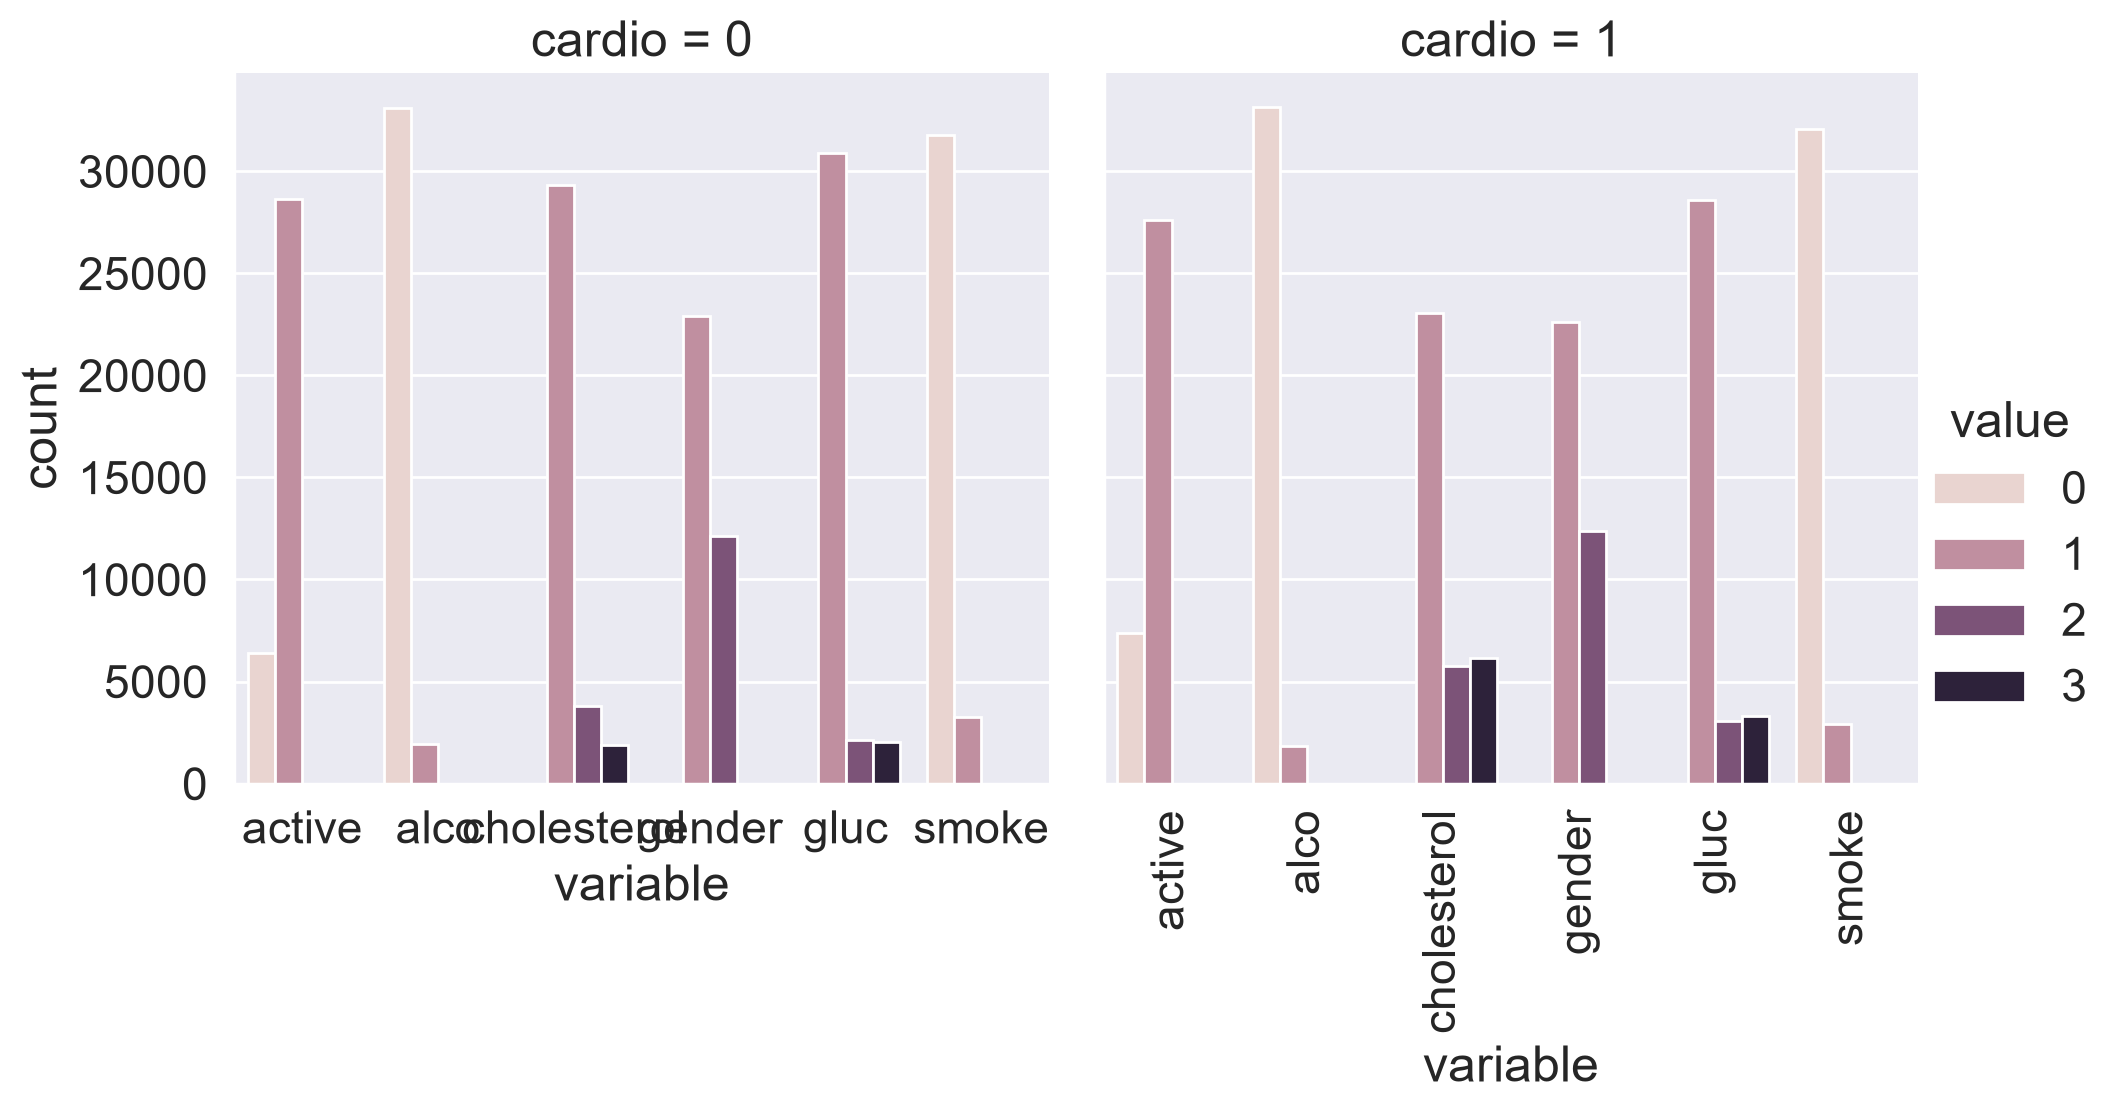

In [58]:
df_uniques = pd.melt(
    frame=df,
    value_vars=["gender", "cholesterol", "gluc", "smoke", "alco", "active"],
    id_vars=["cardio"],
)

df_uniques = (
    pd.DataFrame(df_uniques.groupby(["variable", "value", "cardio"])["value"].count())
    .sort_index(level=[0, 1])
    .rename(columns={"value": "count"})
    .reset_index()
)

sns.catplot(
    x="variable",
    y="count",
    hue="value",
    col="cardio",
    data=df_uniques,
    kind="bar",
)
plt.xticks(rotation='vertical');

In [59]:
for c in df.columns:
    n = df[c].nunique()
    print(c)
    if n <= 3:
        print(n, sorted(df[c].value_counts().to_dict().items()))
    else:
        print(n)
    print(10 * "-")

id
70000
----------
age
8076
----------
gender
2 [(1, 45530), (2, 24470)]
----------
height
109
----------
weight
287
----------
ap_hi
153
----------
ap_lo
157
----------
cholesterol
3 [(1, 52385), (2, 9549), (3, 8066)]
----------
gluc
3 [(1, 59479), (2, 5190), (3, 5331)]
----------
smoke
2 [(0, 63831), (1, 6169)]
----------
alco
2 [(0, 66236), (1, 3764)]
----------
active
2 [(0, 13739), (1, 56261)]
----------
cardio
2 [(0, 35021), (1, 34979)]
----------


Question 1.1. (1 point). How many men and women are present in this dataset? Values of the gender feature were not given (whether “1” stands for women or for men) – figure this out by analyzing height, making the assumption that men are taller on average.

In [60]:
df.groupby('gender', as_index=False)['height'].mean()

,gender,height
0,1,161.355612
1,2,169.947895


(woman 45530), (men 24470)

Question 1.2. (1 point). Who more often report consuming alcohol – men or women?

In [61]:
df.groupby('gender', as_index=False)['alco'].mean()

,gender,alco
0,1,0.025500
1,2,0.106375


men

Question 1.3. (1 point). What’s the rounded difference between the percentages of smokers among men and women?

In [62]:
df_smoke_w = df[df['gender'] == 1]['smoke'].value_counts(normalize=True)

df_smoke_m = df[df['gender'] == 2]['smoke'].value_counts(normalize=True)

df_smoke_m

round((df_smoke_m.loc[1] - df_smoke_w.loc[1]) * 100)




20

Question 1.4. (1 point). What’s the rounded difference between median values of age (in months) for non-smokers and smokers? You’ll need to figure out the units of feature age in this dataset.



In [63]:
df['age'] = df['age'] / 365 * 12

df['age'].head()



0    604.701370
1    665.030137
2    619.956164
3    579.386301
4    574.487671
Name: age, dtype: float64

In [67]:
df_months = df.groupby('smoke')['age'].median()

In [69]:
round(df_months.loc[0] - df_months.loc[1])

20

Let’s take a look at the upper-right rectangle, which shows a subset of smoking men aged from 60 to 65. (It’s not obvious, but the values in the figure represent the upper bound).

We see the value 9 in the lower-left corner of the rectangle and 47 in the upper-right. This means that, for people in this gender-age group whose systolic pressure is less than 120, the risk of a CVD is estimated to be 5 times lower than for those with the pressure in the interval [160,180).

Let’s calculate that same ratio using our data.

Clarifications:

Calculate age_years feature – round age to the nearest number of years. For this task, select only the people of age 60 to 64, inclusive.

Cholesterol level categories differ between the figure and our dataset. The conversion for the cholesterol feature is as follows: 4 mmol/l 
 1, 5-7 mmol/l 
 2, 8 mmol/l 
 3.

In [70]:
df['age_years'] = round(df['age'] / 12)
df['age_years'].head()

0    50.0
1    55.0
2    52.0
3    48.0
4    48.0
Name: age_years, dtype: float64

Question 1.5. (2 points). Calculate fractions of ill people (with CVD) in the two groups of people described in the task. What’s the ratio of these two fractions?

In [78]:
df_60_64 = df[(df['age_years'] >= 60) & (df['age_years'] <= 64)]

df_60_64['age_years'].value_counts()



age_years
60.0    5465
62.0    3926
64.0    3920
61.0    1221
63.0    1016
Name: count, dtype: int64

In [90]:
df_60_64['in_group_120'] = (df_60_64['ap_hi'] <= 120)
df_60_64['in_group_160_180'] = (df_60_64['ap_hi'] <= 180) & (df_60_64['ap_hi'] >= 160)


In [98]:
df_below120 = df_60_64[(df_60_64['smoke'] == 1) & (df_60_64['in_group_120'] == True)].groupby('cardio', as_index=False)['cardio'].count()
df_below120

,cardio
0,260
1,178


In [110]:
df_under160 = df_60_64[(df_60_64['smoke'] == 1) & (df_60_64['in_group_160_180'] == True)].groupby('cardio', as_index=False)['cardio'].count()
df_under160

,cardio
0,13
1,108


In [111]:
ratio_120 = df_below120.loc[1, 'cardio']  / (df_below120.loc[0, 'cardio'] + df_below120.loc[1, 'cardio'])
ratio_120

np.float64(0.4063926940639269)

In [112]:
ratio_160 = df_under160.loc[1, 'cardio'] / (df_under160.loc[0, 'cardio'] + df_under160.loc[1, 'cardio'])
ratio_160


np.float64(0.8925619834710744)

In [114]:
answer = round(ratio_160 / ratio_120)
answer

2

1.3. Analyzing BMI
Task:
Create a new feature – BMI (Body Mass Index). To do this, divide weight in kilograms by the square of the height in meters. Normal BMI values are said to be from 18.5 to 25.

# You code here (read-only in a JupyterBook, pls run jupyter-notebook to edit)

In [118]:
df['BMI'] = df['weight'] / ((df['height'] / 100 ) * (df['height'] / 100 ))

df['BMI'].head()

df_60_64['BMI'] = df['BMI']

df_60_64['BMI'].head()

5     29.384676
6     37.729725
7     29.983588
10    28.010224
19    21.338211
Name: BMI, dtype: float64

Question 1.6. (2 points). Choose the correct statements:

Median BMI in the sample is within boundaries of normal values.

Women’s BMI is on average higher than men’s.

Healthy people have higher median BMI than ill people.

In the segment of healthy and non-drinking men BMI is closer to the norm than in the segment of healthy and non-drinking women

In [119]:
18.5 <= df_60_64['BMI'].median() <= 25

np.False_

In [121]:
df_60_64[df_60_64['gender'] == 1]['BMI'].mean() > df_60_64[df_60_64['gender'] == 2]['BMI'].mean() 

np.True_

In [122]:
df_60_64[df_60_64['cardio'] == 0]['BMI'].median() > df_60_64[df_60_64['cardio'] == 1]['BMI'].median()

np.False_

In [125]:
df_m = df_60_64[(df_60_64['gender'] == 2) & (df_60_64['cardio'] == 0) & (df_60_64['alco'] == 0)]['BMI'].mean() 
df_w = df_60_64[(df_60_64['gender'] == 1) & (df_60_64['cardio'] == 0) & (df_60_64['alco'] == 0)]['BMI'].mean() 
df_m, df_w

(np.float64(26.317229467568065), np.float64(27.755452676882896))

yes

1.4. Cleaning data
Task:
We can see that the data is not perfect. It contains “dirt” and inaccuracies. We’ll see this better as we visualize the data.

Filter out the following patient segments (we consider these as erroneous data)

diastolic pressure is higher than systolic.

height is strictly less than 2.5 percentile (Use pd.Series.quantile to compute this value. If you are not familiar with the function, please read the docs.)

height is strictly more than 97.5 percentile

weight is strictly less than 2.5 percentile

weight is strictly more than 97.5 percentile

This is not everything that we can do to clean this data, but this is sufficient for now.

# You code here (read-only in a JupyterBook, pls run jupyter-notebook to edit)
Question 1.7. (2 points). What percent of the original data (rounded) did we filter out in the previous step?

In [136]:
df_filter = df[(df['ap_hi'] < df['ap_lo']) | 
               (df['height'] < pd.Series.quantile(df['height'], 0.025)) | 
               (df['height'] > pd.Series.quantile(df['height'], 0.975)) | 
               (df['weight'] < pd.Series.quantile(df['weight'], 0.025)) | 
               (df['weight'] > pd.Series.quantile(df['weight'], 0.975))]

len(df_filter)

6741

In [139]:
round(len(df_filter) / len(df) * 100)


10

In [140]:
corr_matrix = df.corr()
corr_matrix

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,BMI
id,1.000000,0.003457,0.003502,-0.003038,-0.001830,0.003356,-0.002529,0.006106,0.002467,-0.003699,0.001210,0.003755,0.003799,0.003050,-0.001377
age,0.003457,1.000000,-0.022811,-0.081515,0.053684,0.020764,0.017647,0.154424,0.098703,-0.047633,-0.029723,-0.009927,0.238159,0.999090,0.085512
gender,0.003502,-0.022811,1.000000,0.499033,0.155406,0.006005,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109,-0.023017,-0.096529
height,-0.003038,-0.081515,0.499033,1.000000,0.290968,0.005488,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821,-0.081456,-0.290642
weight,-0.001830,0.053684,0.155406,0.290968,1.000000,0.030702,0.043710,0.141768,0.106857,0.067780,0.067113,-0.016867,0.181660,0.053661,0.762009
ap_hi,0.003356,0.020764,0.006005,0.005488,0.030702,1.000000,0.016086,0.023778,0.011841,-0.000922,0.001408,-0.000033,0.054475,0.020793,0.024852
ap_lo,-0.002529,0.017647,0.015254,0.006150,0.043710,0.016086,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719,0.017754,0.035345
cholesterol,0.006106,0.154424,-0.035821,-0.050226,0.141768,0.023778,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147,0.154386,0.146270
gluc,0.002467,0.098703,-0.020491,-0.018595,0.106857,0.011841,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307,0.098596,0.101390
smoke,-0.003699,-0.047633,0.338135,0.187989,0.067780,-0.000922,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486,-0.047884,-0.027215


<Axes: >

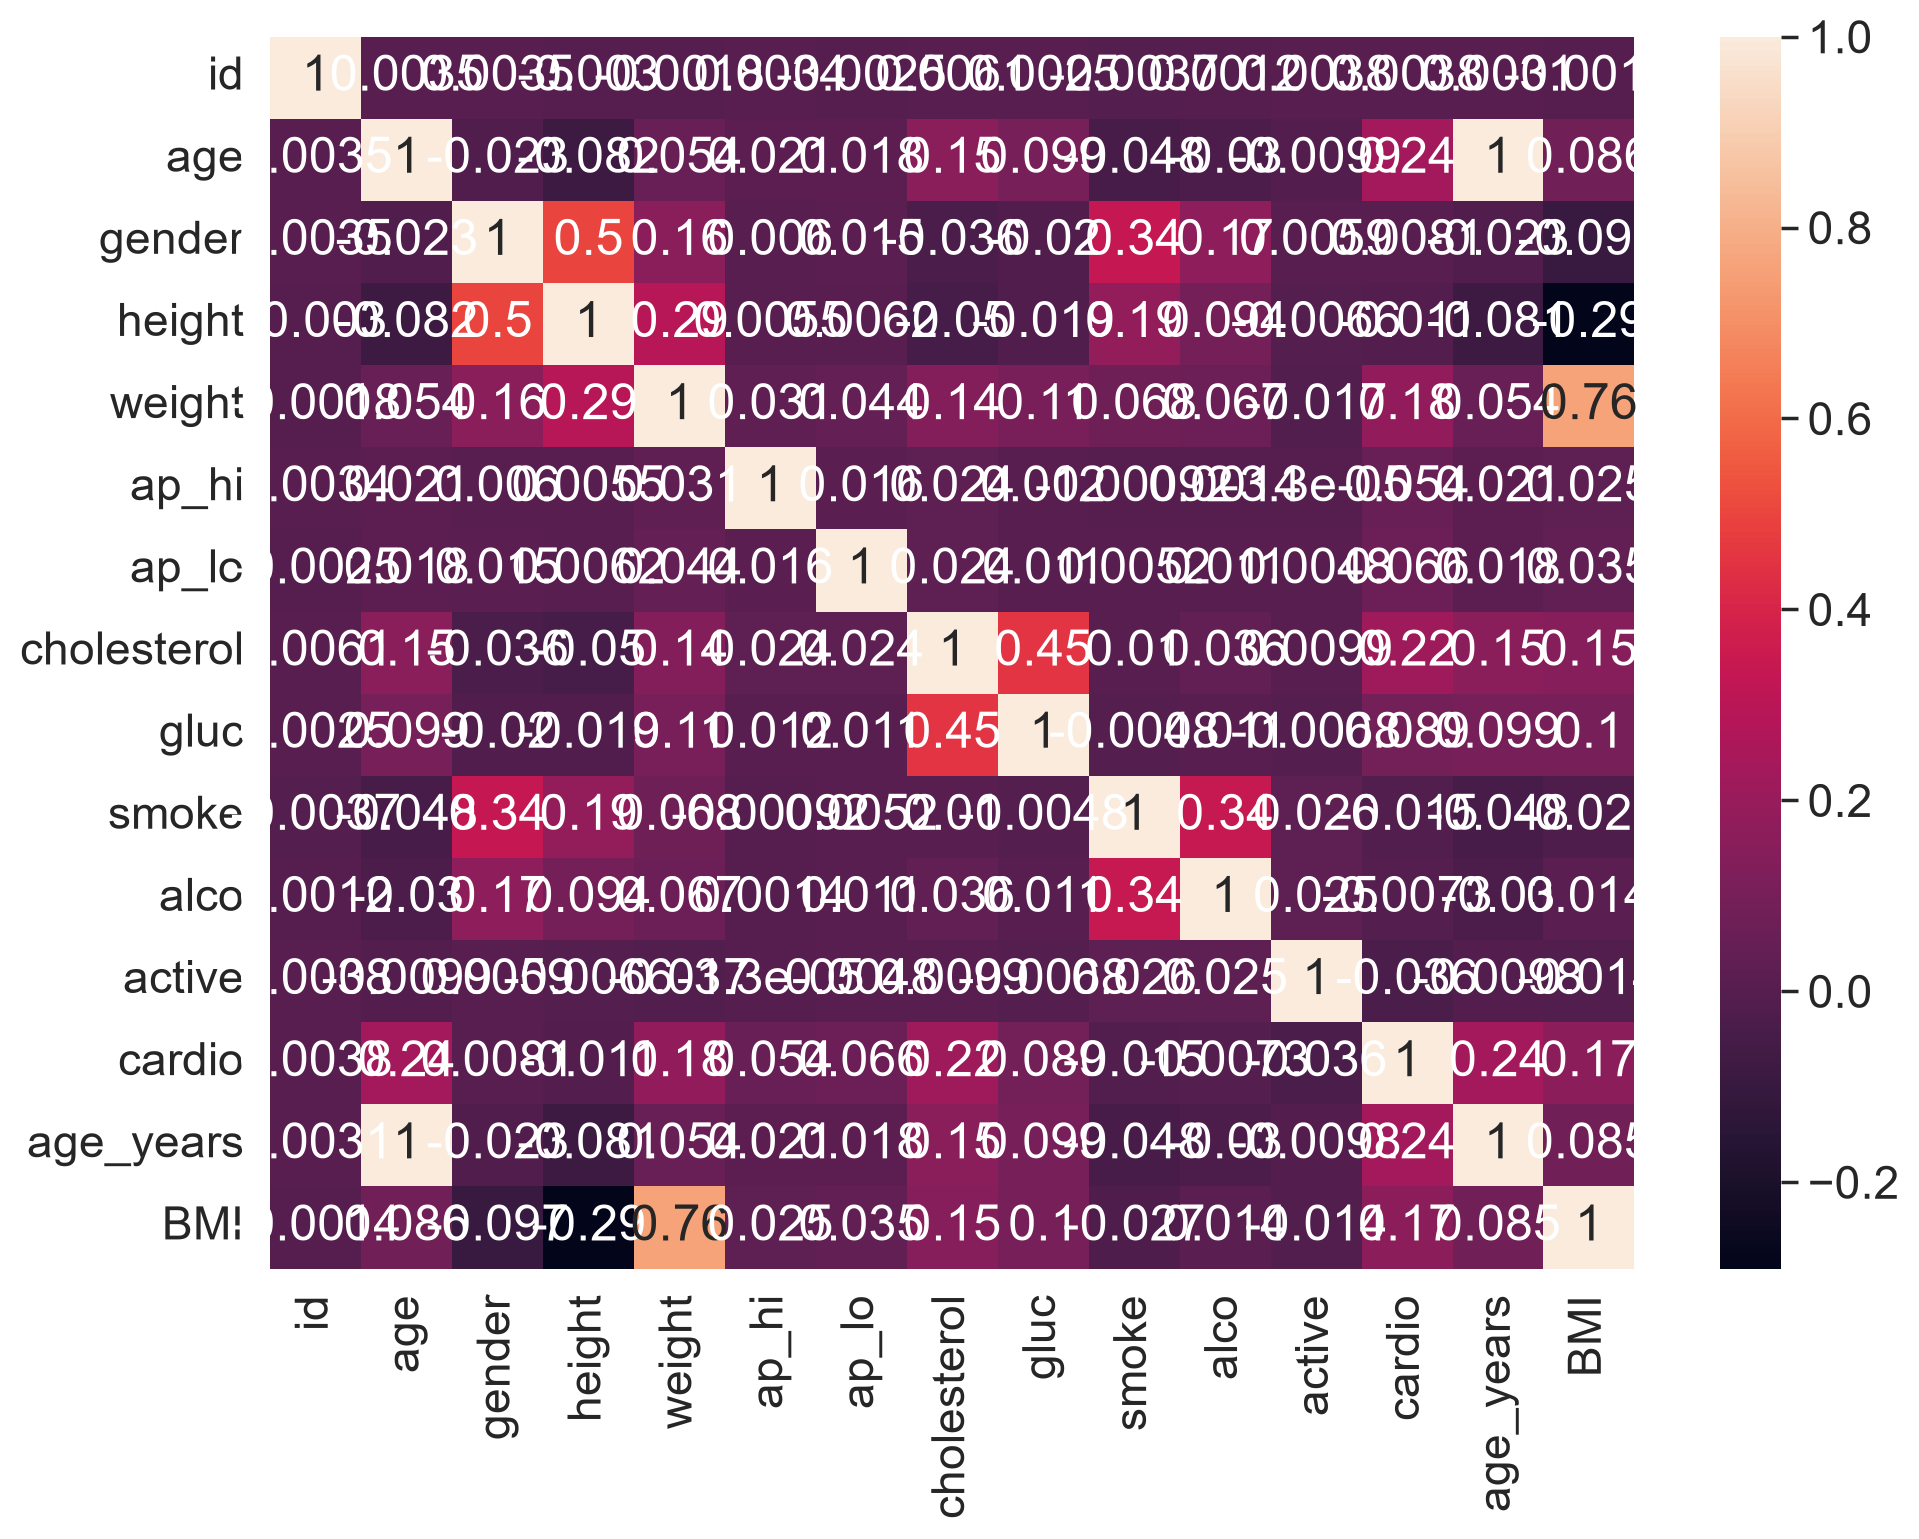

In [142]:
sns.heatmap(corr_matrix, annot=True)

In [144]:
corr_matrix = df[['cardio', 'cholesterol', 'height', 'smoke', 'alco', 'weight']].corr()
corr_matrix

,cardio,cholesterol,height,smoke,alco,weight
cardio,1.000000,0.221147,-0.010821,-0.015486,-0.007330,0.181660
cholesterol,0.221147,1.000000,-0.050226,0.010354,0.035760,0.141768
height,-0.010821,-0.050226,1.000000,0.187989,0.094419,0.290968
smoke,-0.015486,0.010354,0.187989,1.000000,0.340094,0.067780
alco,-0.007330,0.035760,0.094419,0.340094,1.000000,0.067113
weight,0.181660,0.141768,0.290968,0.067780,0.067113,1.000000


Question 2.1. (1 point). Which pair of features has the strongest Pearson’s correlation with the gender feature?

Cardio, Cholesterol

Height, Smoke

Smoke, Alco

Height, Weight

<Axes: >

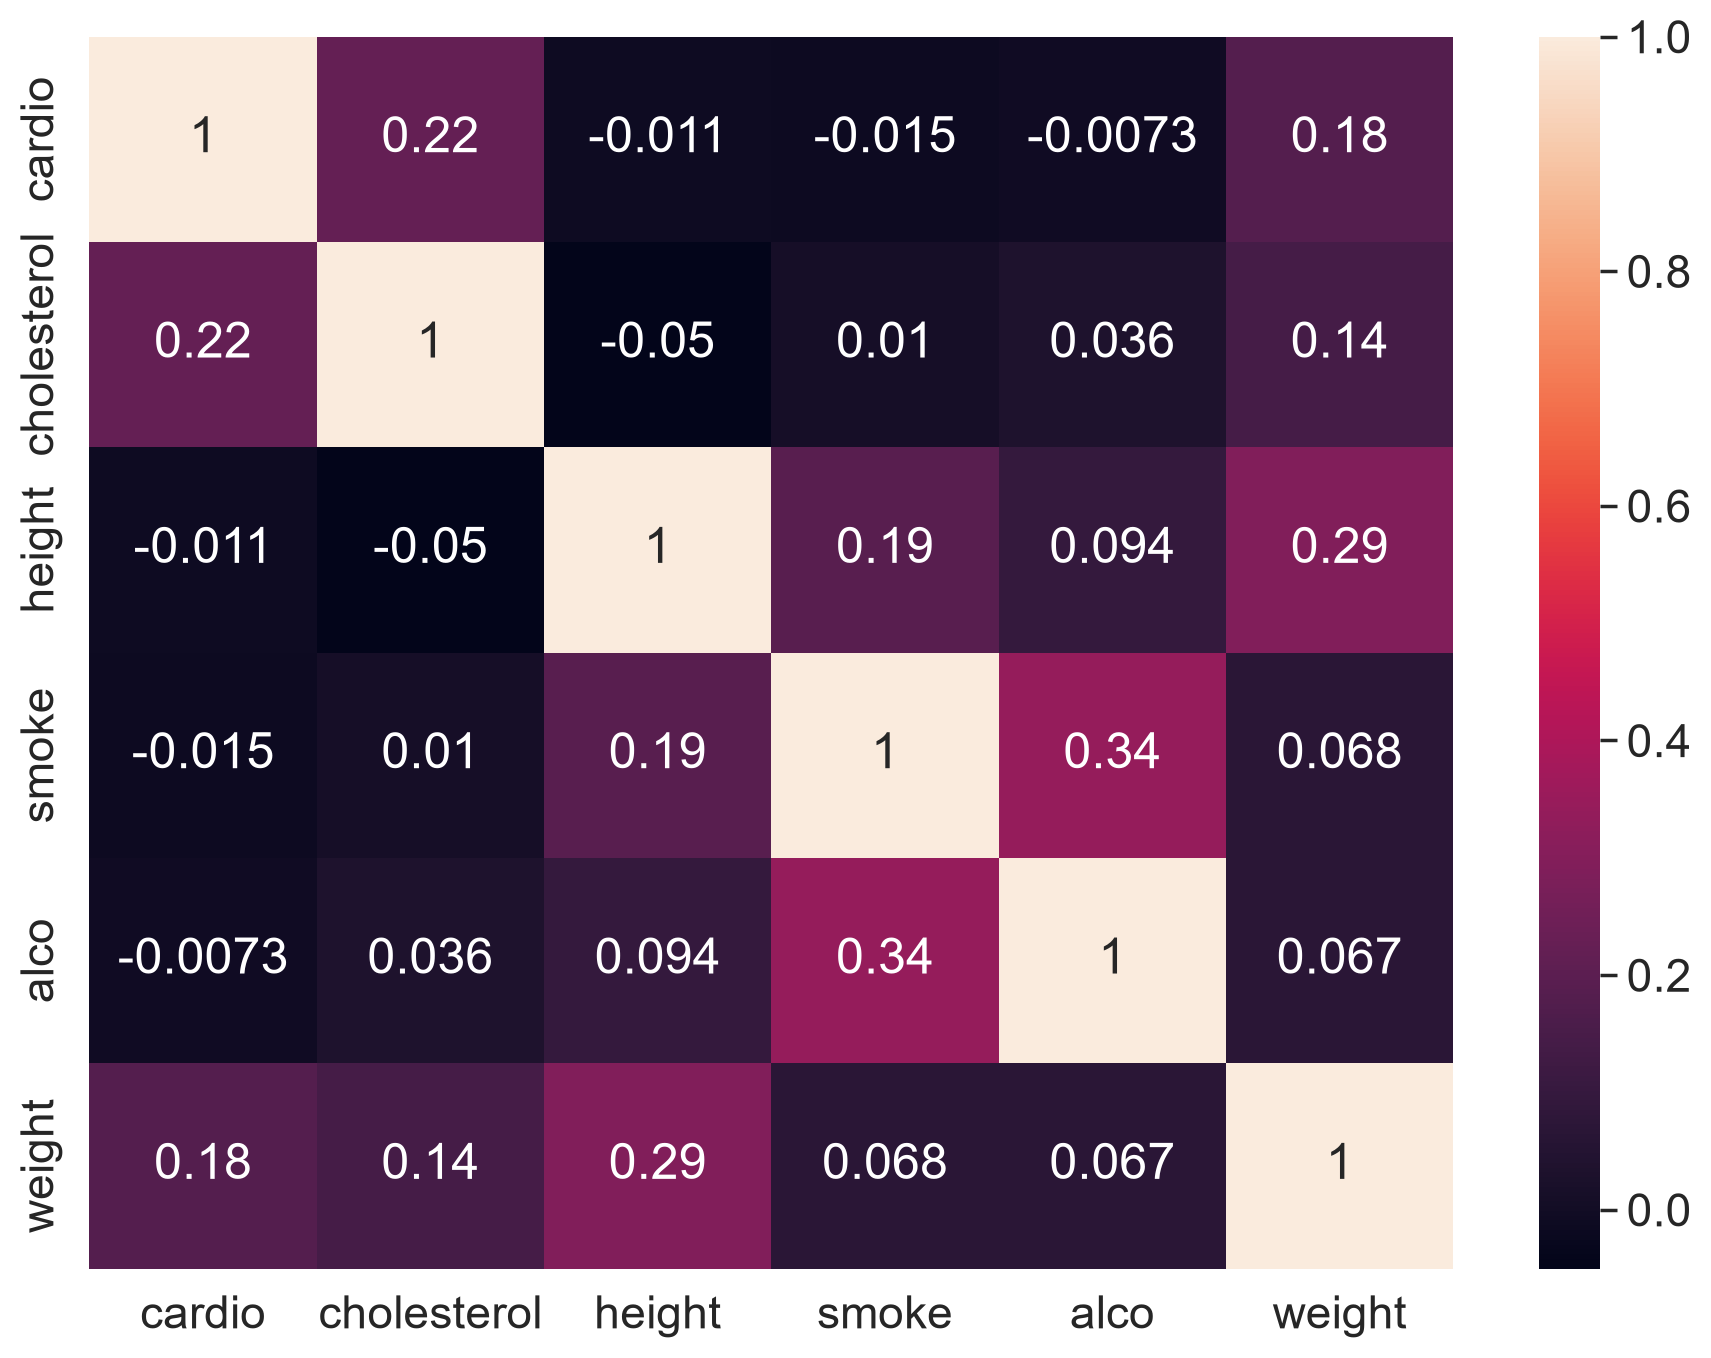

In [145]:
sns.heatmap(corr_matrix, annot=True)

Smoke, Alco

Task:
Create a violin plot for the height and gender using violinplot(). Use the parameters:

hue to split by gender;

scale to evaluate the number of records for each gender.

In order for the plot to render correctly, you need to convert your DataFrame to long format using the melt() function from pandas. Here is an example of this for your reference.

In [155]:
df_melt = df.melt(id_vars='gender', value_vars=['height'], var_name='feature', value_name='value')
df_melt.head()

,gender,feature,value
0,2,height,168
1,1,height,156
2,1,height,165
3,2,height,169
4,1,height,156


<Axes: xlabel='feature', ylabel='value'>

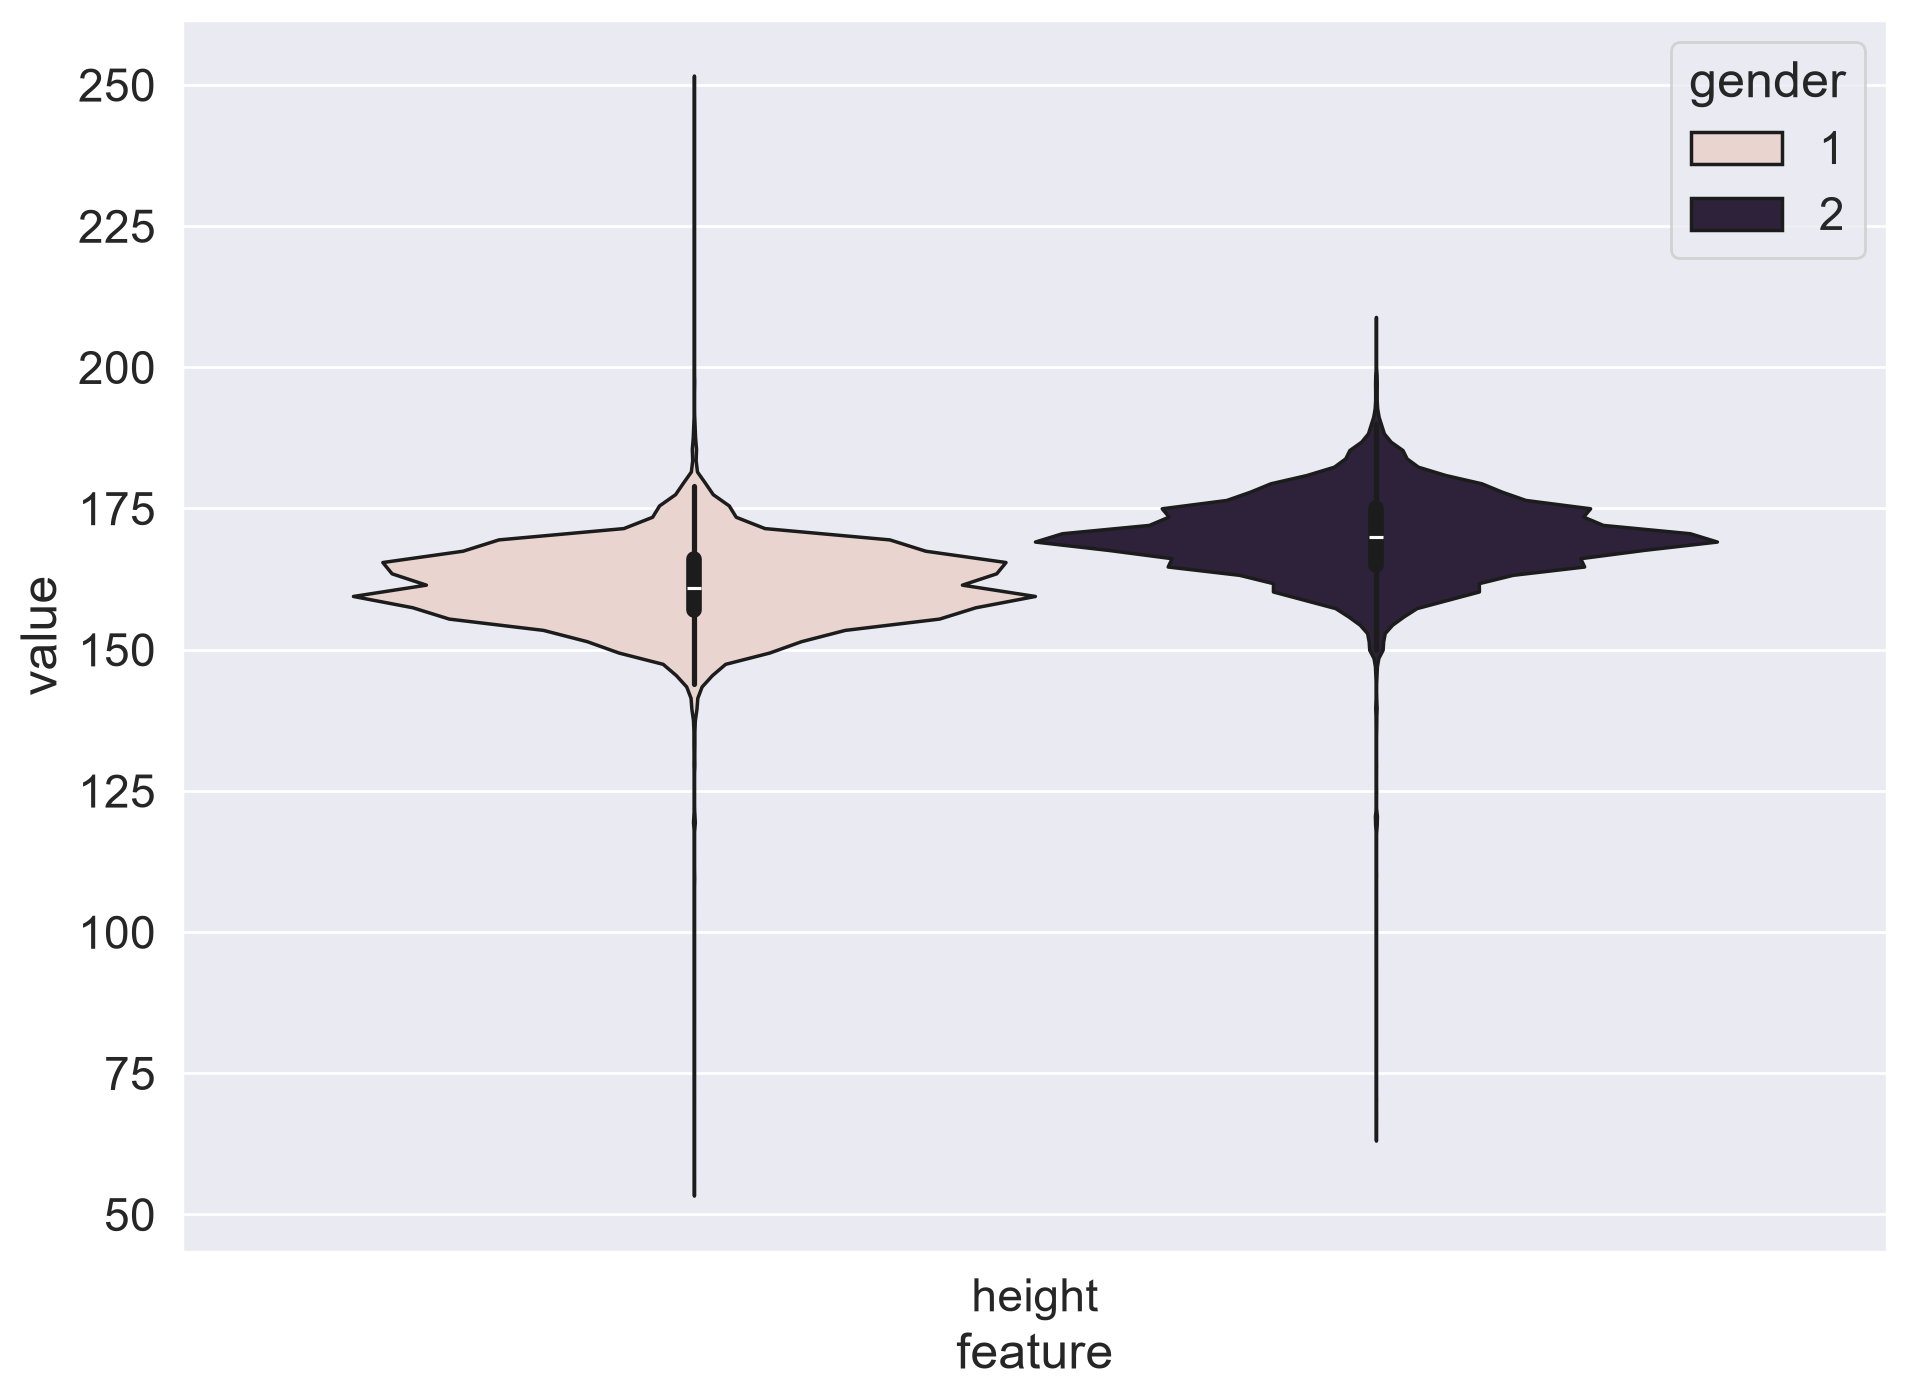

In [156]:
sns.violinplot(data=df_melt, y='value', x='feature', scale='count',  hue='gender')

In [159]:
corr_matrix_rank = df[['height', 'weight', 'age', 'cholesterol', 'gluc', 'cardio', 'alco', 'smoke', 'ap_hi', 'ap_lo']].corr(method='spearman')
corr_matrix_rank

,height,weight,age,cholesterol,gluc,cardio,alco,smoke,ap_hi,ap_lo
height,1.000000,0.313569,-0.082292,-0.058940,-0.024369,-0.012383,0.096670,0.197632,0.019381,0.030534
weight,0.313569,1.000000,0.061559,0.137908,0.109901,0.182701,0.068088,0.071676,0.277749,0.254420
age,-0.082292,0.061559,1.000000,0.140113,0.091791,0.234429,-0.030078,-0.047471,0.219087,0.156700
cholesterol,-0.058940,0.137908,0.140113,1.000000,0.407803,0.215117,0.041285,0.015220,0.208722,0.167401
gluc,-0.024369,0.109901,0.091791,0.407803,1.000000,0.091488,0.018584,0.000468,0.105334,0.082474
cardio,-0.012383,0.182701,0.234429,0.215117,0.091488,1.000000,-0.007330,-0.015486,0.451885,0.362572
alco,0.096670,0.068088,-0.030078,0.041285,0.018584,-0.007330,1.000000,0.340094,0.033243,0.038862
smoke,0.197632,0.071676,-0.047471,0.015220,0.000468,-0.015486,0.340094,1.000000,0.028929,0.026172
ap_hi,0.019381,0.277749,0.219087,0.208722,0.105334,0.451885,0.033243,0.028929,1.000000,0.735436
ap_lo,0.030534,0.254420,0.156700,0.167401,0.082474,0.362572,0.038862,0.026172,0.735436,1.000000


<Axes: >

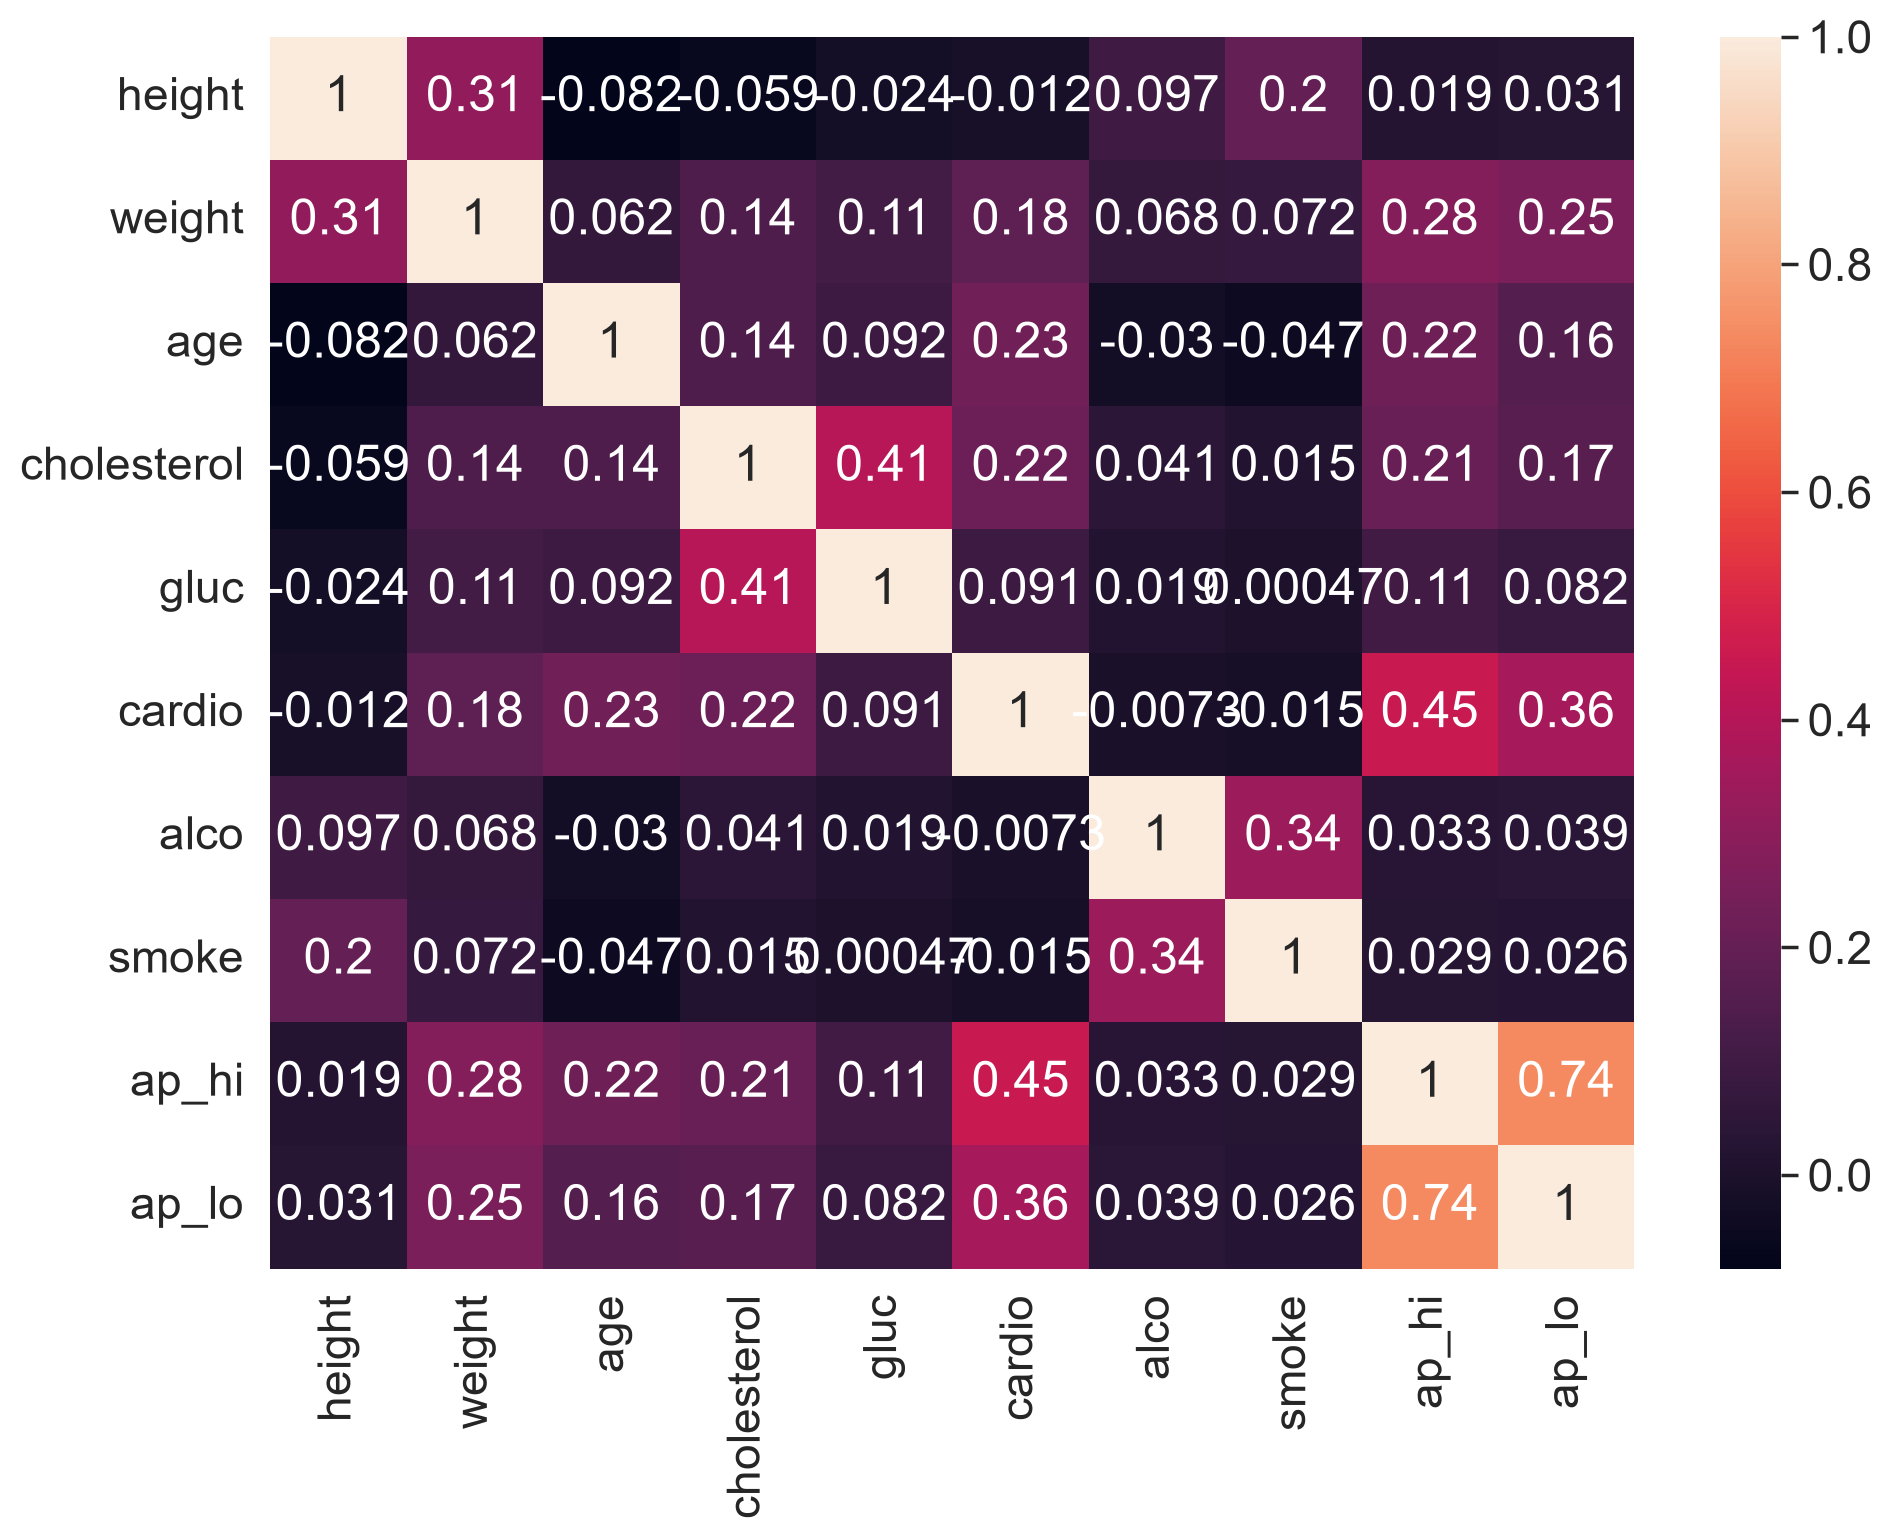

In [161]:
sns.heatmap(corr_matrix_rank, annot=True)

Question 2.2. (1 point). Which pair of features has the strongest Spearman rank correlation?

Height, Weight 0.31

Age, Weight 0.06

Cholesterol, Gluc 0.41

Cardio, Cholesterol 0.22

Ap_hi, Ap_lo 0.74

Smoke, Alco 0.34


Ap_hi, Ap_lo 

Question 2.3. (1 point). Why do these features have strong rank correlation?

Inaccuracies in the data (data acquisition errors).

Relation is wrong, these features should not be related.

Nature of the data.

Nature of the data.

In [162]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'age_years',
       'BMI'],
      dtype='str')

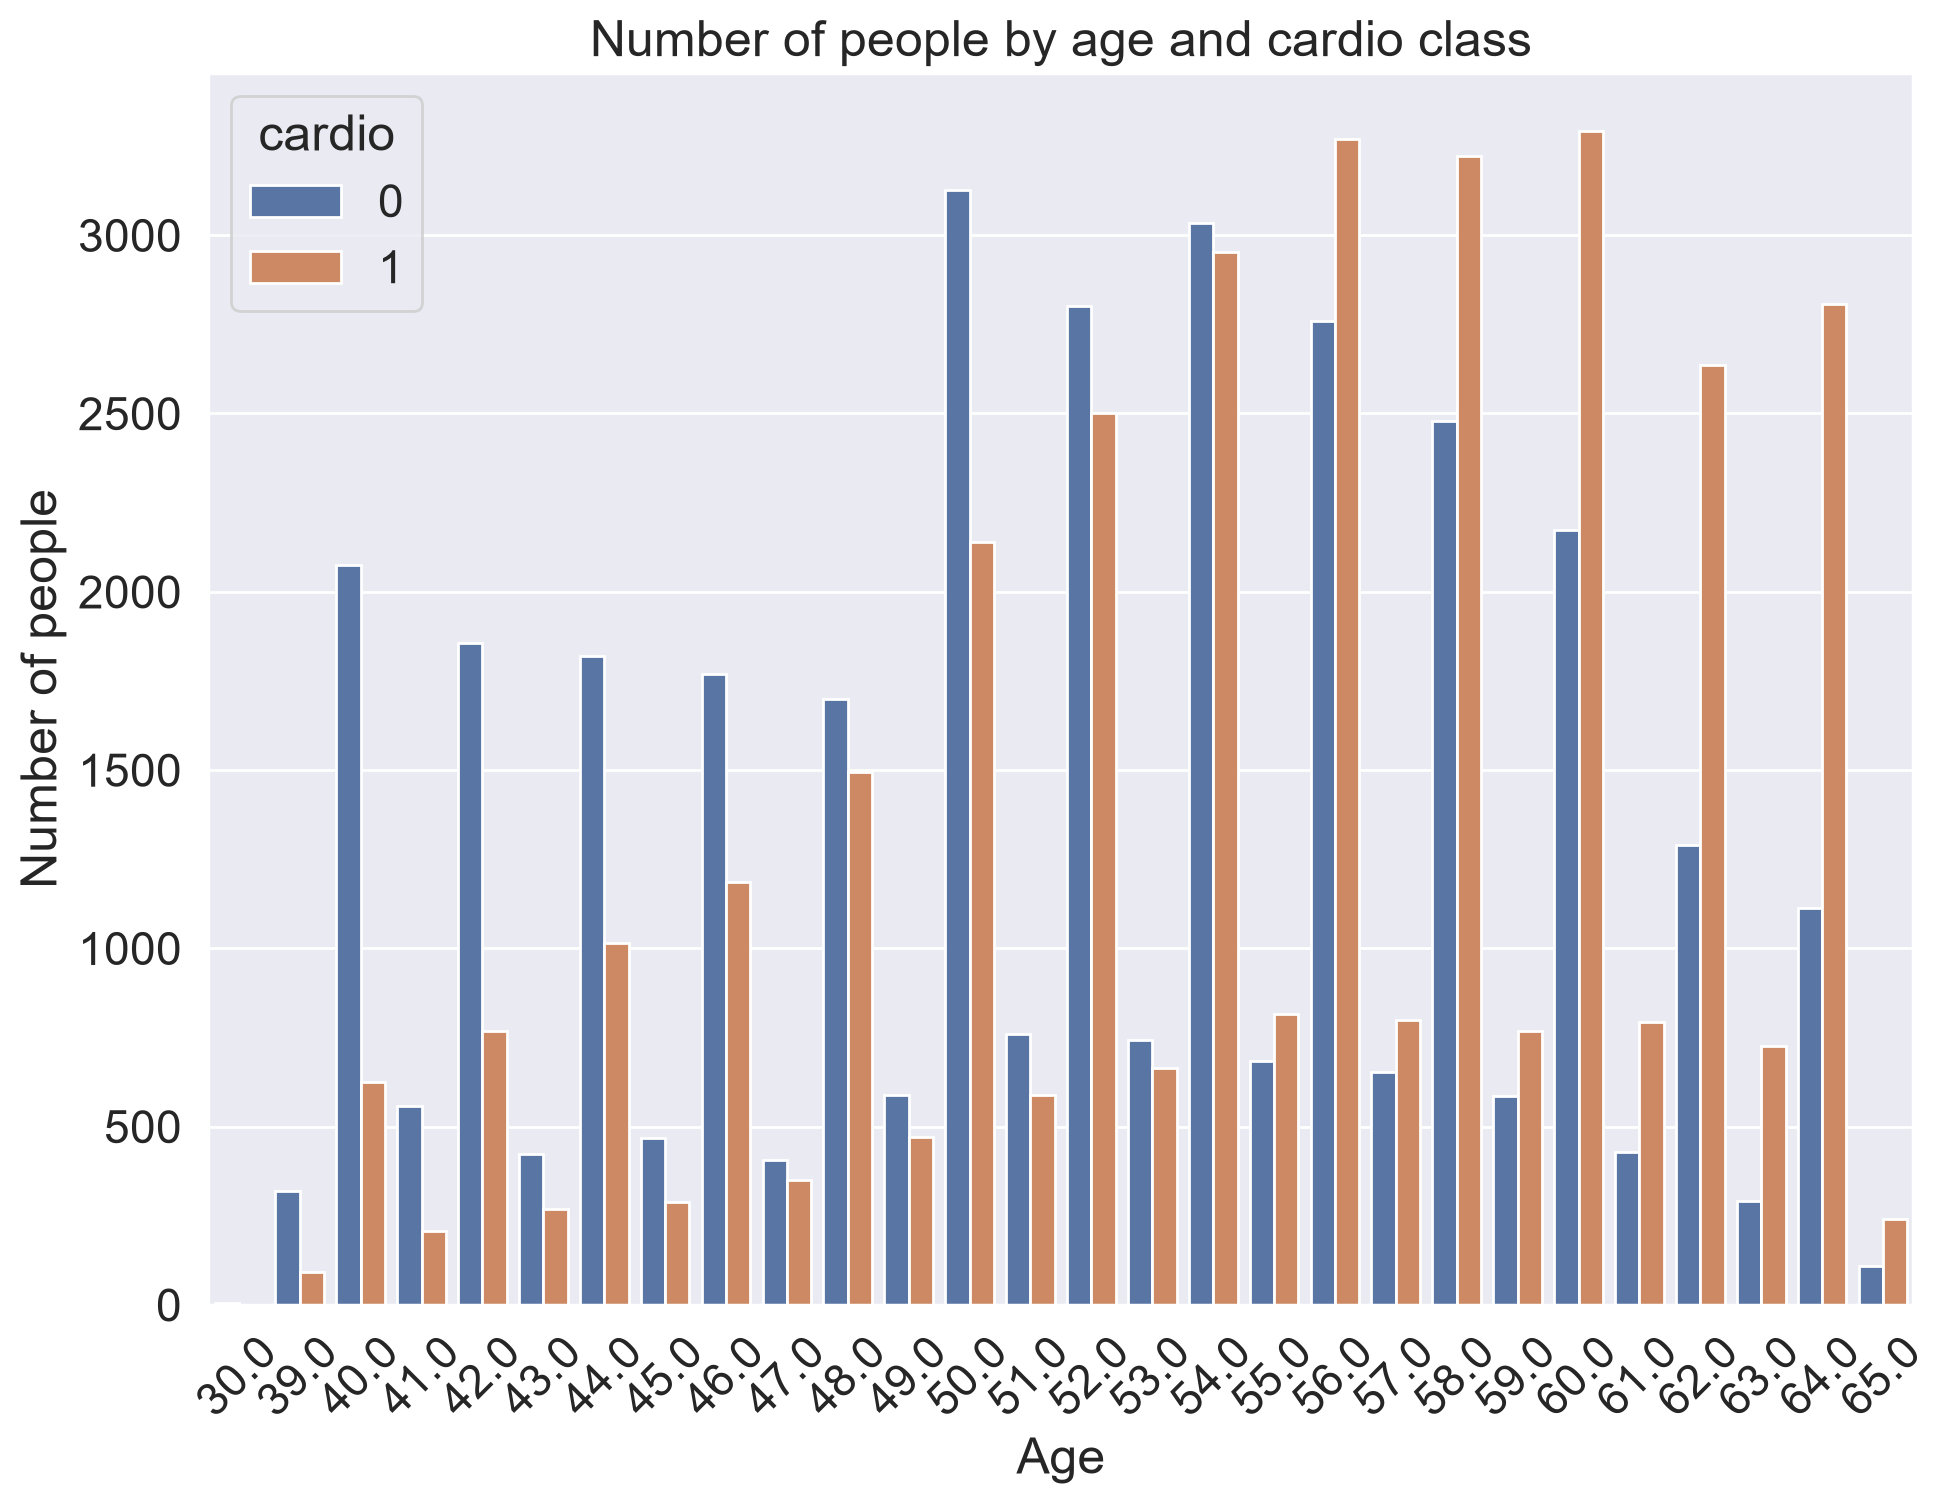

In [166]:
sns.countplot(x='age_years', hue='cardio', data=df)

plt.xlabel("Age")
plt.ylabel("Number of people")
plt.title("Number of people by age and cardio class")
plt.xticks(rotation=45)
plt.show()

Question 2.4. (1 point). What is the smallest age at which the number of people with CVD outnumbers the number of people without CVD?

44

55

64

70

55